load the tools we need

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro

Read the CSV file

In [9]:
df = pd.read_csv("DS_assignment_data - Copy (1) (1).csv")
df.head()

,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,DISBURSAL_DATE,MOBILENO_AVL_FLAG,...,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT
0,420825,50578,58400,89.55,67,1441,01/01/1984,Salaried,03/08/2018,1,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,537409,47145,65550,73.23,67,1502,31/07/1985,Self employed,26/09/2018,1,...,0,0,1991,0,0,1,1yrs 11mon,1yrs 11mon,0,1
2,417566,53278,61360,89.63,67,1497,24/08/1985,Self employed,01/08/2018,1,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
3,624493,57513,66113,88.48,67,1501,30/12/1993,Self employed,26/10/2018,1,...,0,0,31,0,0,0,0yrs 8mon,1yrs 3mon,1,1
4,539055,52378,60300,88.39,67,1495,09/12/1977,Self employed,26/09/2018,1,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,1,1


In [ ]:
#Checks row and column count, column names, data types, and missing values
print(df.shape)
print(df.columns.tolist())
print(df.info())
print(df.isna().sum())

   UNIQUEID  DISBURSED_AMOUNT  ASSET_COST    LTV  BRANCH_ID  \
0    420825             50578       58400  89.55         67   
1    537409             47145       65550  73.23         67   
2    417566             53278       61360  89.63         67   
3    624493             57513       66113  88.48         67   
4    539055             52378       60300  88.39         67   

   CURRENT_PINCODE_ID DATE_OF_BIRTH EMPLOYMENT_TYPE DISBURSAL_DATE  \
0                1441    01/01/1984        Salaried     03/08/2018   
1                1502    31/07/1985   Self employed     26/09/2018   
2                1497    24/08/1985   Self employed     01/08/2018   
3                1501    30/12/1993   Self employed     26/10/2018   
4                1495    09/12/1977   Self employed     26/09/2018   

   MOBILENO_AVL_FLAG  ...  SEC_SANCTIONED_AMOUNT  SEC_DISBURSED_AMOUNT  \
0                  1  ...                      0                     0   
1                  1  ...                      0    

Convert dates and create

In [10]:
df["DATE_OF_BIRTH"] = pd.to_datetime(df["DATE_OF_BIRTH"], errors="coerce", dayfirst=True)
df["DISBURSAL_DATE"] = pd.to_datetime(df["DISBURSAL_DATE"], errors="coerce", dayfirst=True)

df["AGE_YEARS"] = (df["DISBURSAL_DATE"] - df["DATE_OF_BIRTH"]).dt.days / 365.25
df.loc[(df["AGE_YEARS"] < 18) | (df["AGE_YEARS"] > 100), "AGE_YEARS"] = np.nan

print(df["AGE_YEARS"].describe())

count    5000.000000
mean       34.781669
std         9.870244
min        18.078029
25%        26.540726
50%        32.896646
75%        41.735797
max        64.010951
Name: AGE_YEARS, dtype: float64


create a smaller modelling dataset

In [11]:
model_df = df[
    [
        "DISBURSED_AMOUNT",
        "PERFORM_CNS_SCORE",
        "ASSET_COST",
        "LTV",
        "EMPLOYMENT_TYPE",
        "DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS",
        "NO_OF_INQUIRIES",
        "AGE_YEARS"
    ]
].copy()

handle missing data

In [12]:
print(model_df.isna().sum())

model_df["EMPLOYMENT_TYPE"] = model_df["EMPLOYMENT_TYPE"].fillna("Unknown")
model_df = model_df.dropna()

print(model_df.shape)
print(model_df.isna().sum())

DISBURSED_AMOUNT                         0
PERFORM_CNS_SCORE                        0
ASSET_COST                               0
LTV                                      0
EMPLOYMENT_TYPE                        144
DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS      0
NO_OF_INQUIRIES                          0
AGE_YEARS                                0
dtype: int64
(5000, 8)
DISBURSED_AMOUNT                       0
PERFORM_CNS_SCORE                      0
ASSET_COST                             0
LTV                                    0
EMPLOYMENT_TYPE                        0
DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS    0
NO_OF_INQUIRIES                        0
AGE_YEARS                              0
dtype: int64


look at summary statistics and distributions

In [13]:
print(model_df.describe())

       DISBURSED_AMOUNT  PERFORM_CNS_SCORE     ASSET_COST          LTV  \
count       5000.000000        5000.000000    5000.000000  5000.000000   
mean       52618.059800         261.070000   75361.666000    72.859102   
std        11356.022842         332.599411   16511.840509    11.417345   
min        13990.000000           0.000000   39605.000000    17.050000   
25%        46176.750000           0.000000   65831.000000    66.837500   
50%        52603.000000           0.000000   70764.000000    74.850000   
75%        58585.000000         651.000000   78800.250000    80.610000   
max       151143.000000         879.000000  225100.000000    94.990000   

       DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS  NO_OF_INQUIRIES    AGE_YEARS  
count                           5000.00000       5000.00000  5000.000000  
mean                               0.08860          0.19120    34.781669  
std                                0.35941          0.76887     9.870244  
min                              

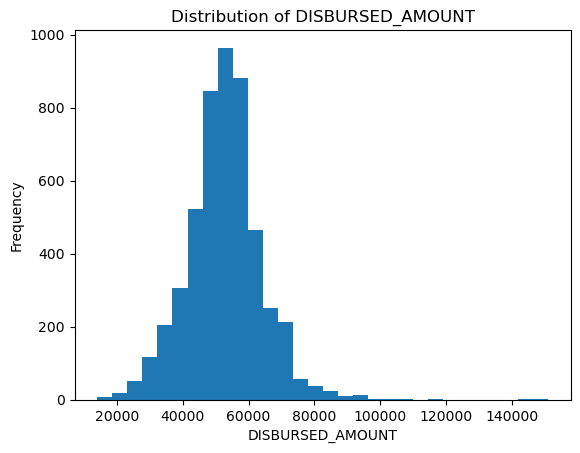

In [14]:
plt.hist(model_df["DISBURSED_AMOUNT"], bins=30)
plt.xlabel("DISBURSED_AMOUNT")
plt.ylabel("Frequency")
plt.title("Distribution of DISBURSED_AMOUNT")
plt.show()

                                     DISBURSED_AMOUNT  PERFORM_CNS_SCORE  \
DISBURSED_AMOUNT                             1.000000          -0.032883   
PERFORM_CNS_SCORE                           -0.032883           1.000000   
ASSET_COST                                   0.696747          -0.119746   
LTV                                          0.438774           0.104651   
DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS          0.052429           0.174144   
NO_OF_INQUIRIES                              0.020236           0.170999   
AGE_YEARS                                   -0.064788           0.148007   

                                     ASSET_COST       LTV  \
DISBURSED_AMOUNT                       0.696747  0.438774   
PERFORM_CNS_SCORE                     -0.119746  0.104651   
ASSET_COST                             1.000000 -0.318510   
LTV                                   -0.318510  1.000000   
DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS    0.005061  0.064208   
NO_OF_INQUIRIES          

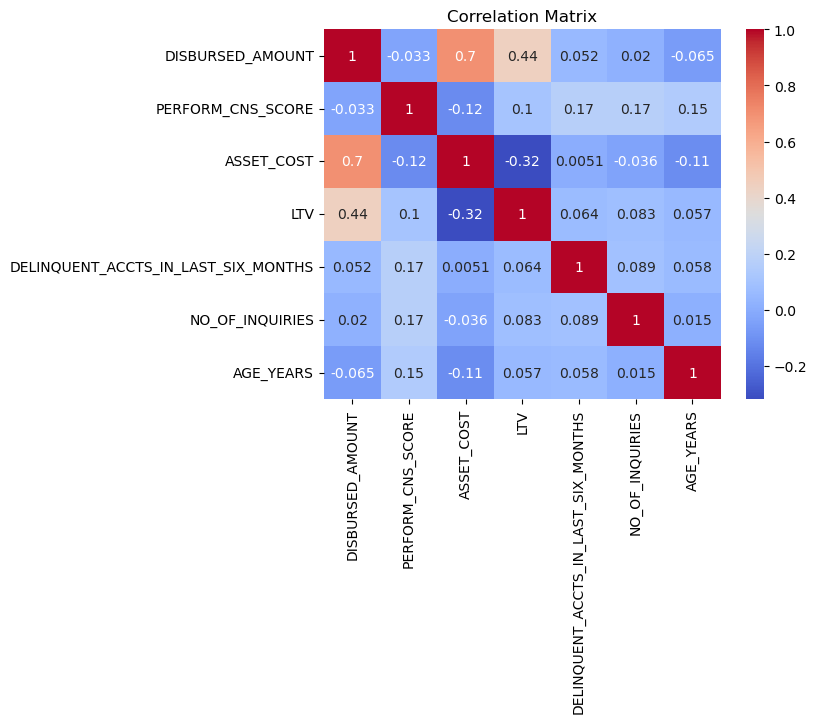

In [15]:
numeric_cols = [
    "DISBURSED_AMOUNT",
    "PERFORM_CNS_SCORE",
    "ASSET_COST",
    "LTV",
    "DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS",
    "NO_OF_INQUIRIES",
    "AGE_YEARS"
]

corr = model_df[numeric_cols].corr()
print(corr)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

loan amount is often skewed, and log transformation often gives a better regression model.

In [16]:
model_df["LOG_DISBURSED_AMOUNT"] = np.log(model_df["DISBURSED_AMOUNT"])

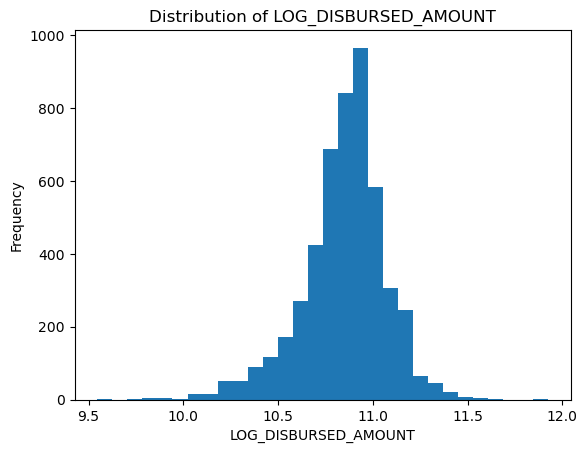

In [17]:
plt.hist(model_df["LOG_DISBURSED_AMOUNT"], bins=30)
plt.xlabel("LOG_DISBURSED_AMOUNT")
plt.ylabel("Frequency")
plt.title("Distribution of LOG_DISBURSED_AMOUNT")
plt.show()

run the multiple regression and It estimates the effect of each variable while controlling for the others.

In [ ]:
model1 = smf.ols(
    "DISBURSED_AMOUNT ~ PERFORM_CNS_SCORE + ASSET_COST + LTV + C(EMPLOYMENT_TYPE) + DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS + NO_OF_INQUIRIES + AGE_YEARS",
    data=model_df
).fit()

print(model1.summary()) #Raw Model

                            OLS Regression Results                            
Dep. Variable:       DISBURSED_AMOUNT   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                 2.128e+04
Date:                Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:11:44   Log-Likelihood:                -44885.
No. Observations:                5000   AIC:                         8.979e+04
Df Residuals:                    4991   BIC:                         8.985e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [19]:
model2 = smf.ols(
    "LOG_DISBURSED_AMOUNT ~ PERFORM_CNS_SCORE + ASSET_COST + LTV + C(EMPLOYMENT_TYPE) + DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS + NO_OF_INQUIRIES + AGE_YEARS",
    data=model_df
).fit()

print(model2.summary())

                             OLS Regression Results                             
Dep. Variable:     LOG_DISBURSED_AMOUNT   R-squared:                       0.954
Model:                              OLS   Adj. R-squared:                  0.954
Method:                   Least Squares   F-statistic:                 1.290e+04
Date:                  Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                          15:12:37   Log-Likelihood:                 8006.6
No. Observations:                  5000   AIC:                        -1.600e+04
Df Residuals:                      4991   BIC:                        -1.594e+04
Df Model:                             8                                         
Covariance Type:              nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

test whether the regression behaves reasonably well.

In [20]:
fitted = model2.fittedvalues
residuals = model2.resid

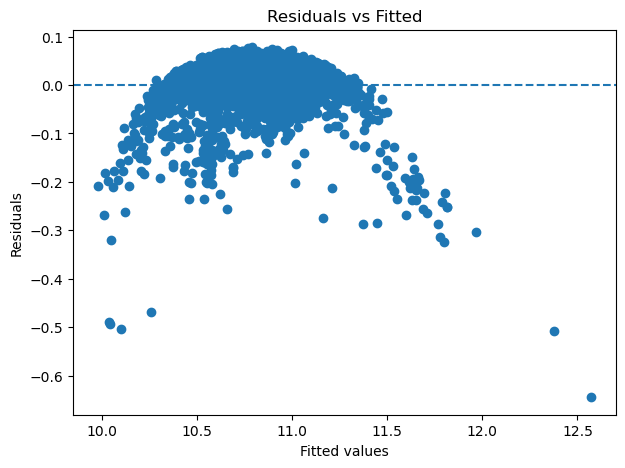

In [21]:
plt.figure(figsize=(7, 5))
plt.scatter(fitted, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

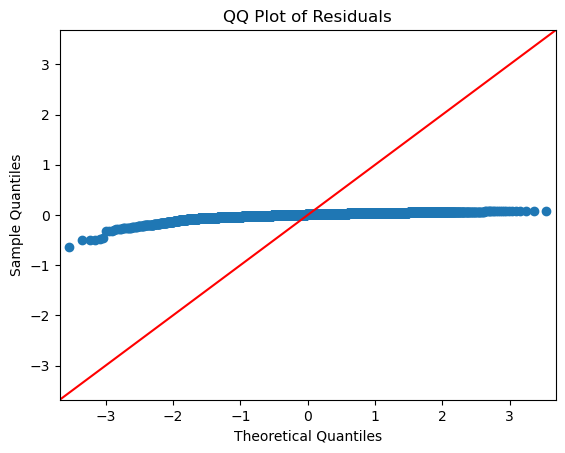

In [22]:
sm.qqplot(residuals, line="45")
plt.title("QQ Plot of Residuals")
plt.show()

In [23]:
sample_resid = residuals.sample(min(500, len(residuals)), random_state=42)
stat, p_value = shapiro(sample_resid)

print("Shapiro-Wilk test statistic:", stat)
print("Shapiro-Wilk p-value:", p_value)

Shapiro-Wilk test statistic: 0.7851350873111987
Shapiro-Wilk p-value: 3.920079149388947e-25


In [24]:
bp_test = het_breuschpagan(residuals, model2.model.exog)
bp_labels = ["LM Statistic", "LM p-value", "F Statistic", "F p-value"]
print(dict(zip(bp_labels, bp_test)))

{'LM Statistic': 433.83564965091716, 'LM p-value': 1.0728529169810649e-88, 'F Statistic': 59.274961468540624, 'F p-value': 7.347761511644787e-93}


In [25]:
model2_robust = model2.get_robustcov_results(cov_type="HC3")
print(model2_robust.summary())

                             OLS Regression Results                             
Dep. Variable:     LOG_DISBURSED_AMOUNT   R-squared:                       0.954
Model:                              OLS   Adj. R-squared:                  0.954
Method:                   Least Squares   F-statistic:                     2066.
Date:                  Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                          15:17:16   Log-Likelihood:                 8006.6
No. Observations:                  5000   AIC:                        -1.600e+04
Df Residuals:                      4991   BIC:                        -1.594e+04
Df Model:                             8                                         
Covariance Type:                    HC3                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

In [27]:
X = pd.get_dummies(
    model_df[
        [
            "PERFORM_CNS_SCORE",
            "ASSET_COST",
            "LTV",
            "EMPLOYMENT_TYPE",
            "DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS",
            "NO_OF_INQUIRIES",
            "AGE_YEARS"
        ]
    ],
    drop_first=True
)

X = X.astype(float)
X = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df)

                              Variable         VIF
0                                const  108.450222
1                    PERFORM_CNS_SCORE    1.096820
2                           ASSET_COST    1.136750
3                                  LTV    1.146948
4  DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS    1.040723
5                      NO_OF_INQUIRIES    1.038440
6                            AGE_YEARS    1.067307
7        EMPLOYMENT_TYPE_Self employed    1.066393
8              EMPLOYMENT_TYPE_Unknown    1.059825


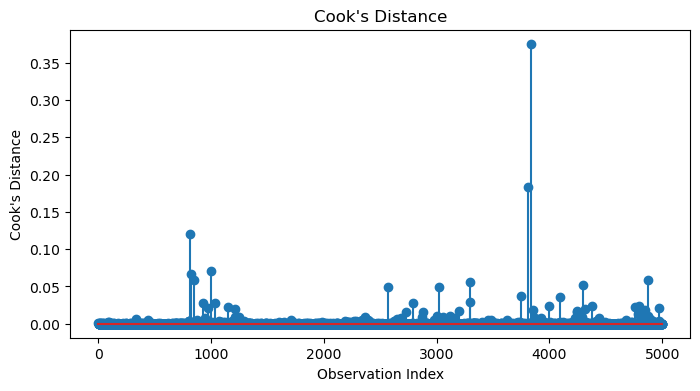

In [28]:
influence = model2.get_influence()
cooks_d, _ = influence.cooks_distance

plt.figure(figsize=(8, 4))
plt.stem(range(len(cooks_d)), cooks_d)
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance")
plt.show()

organizing coefficients and p-values.

In [29]:
results_table = pd.DataFrame({
    "Coefficient": model2_robust.params,
    "p_value": model2_robust.pvalues
})

results_table["Approx_%_change"] = (np.exp(results_table["Coefficient"]) - 1) * 100
print(results_table)

   Coefficient   p_value  Approx_%_change
0     8.787394  0.000000    655013.865920
1    -0.001327  0.349797        -0.132573
2     0.004819  0.403486         0.483052
3    -0.000004  0.064909        -0.000372
4     0.000012  0.000000         0.001188
5     0.016067  0.000000         1.619627
6    -0.003034  0.142753        -0.302920
7    -0.002612  0.013613        -0.260835
8    -0.000131  0.054647        -0.013138


In [31]:
print(results_table.head())
print(vif_df.head())

   Coefficient   p_value  Approx_%_change
0     8.787394  0.000000    655013.865920
1    -0.001327  0.349797        -0.132573
2     0.004819  0.403486         0.483052
3    -0.000004  0.064909        -0.000372
4     0.000012  0.000000         0.001188
                              Variable         VIF
0                                const  108.450222
1                    PERFORM_CNS_SCORE    1.096820
2                           ASSET_COST    1.136750
3                                  LTV    1.146948
4  DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS    1.040723


In [32]:
results_table.to_csv("assignment1_coefficients.csv")
vif_df.to_csv("assignment1_vif.csv")

print("Files saved successfully!")

Files saved successfully!


In [33]:
print(model2_robust.summary())
print(results_table)

                             OLS Regression Results                             
Dep. Variable:     LOG_DISBURSED_AMOUNT   R-squared:                       0.954
Model:                              OLS   Adj. R-squared:                  0.954
Method:                   Least Squares   F-statistic:                     2066.
Date:                  Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                          15:24:51   Log-Likelihood:                 8006.6
No. Observations:                  5000   AIC:                        -1.600e+04
Df Residuals:                      4991   BIC:                        -1.594e+04
Df Model:                             8                                         
Covariance Type:                    HC3                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

In [34]:
print(model2_robust.summary())
print(results_table)
print(vif_df)

                             OLS Regression Results                             
Dep. Variable:     LOG_DISBURSED_AMOUNT   R-squared:                       0.954
Model:                              OLS   Adj. R-squared:                  0.954
Method:                   Least Squares   F-statistic:                     2066.
Date:                  Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                          15:25:14   Log-Likelihood:                 8006.6
No. Observations:                  5000   AIC:                        -1.600e+04
Df Residuals:                      4991   BIC:                        -1.594e+04
Df Model:                             8                                         
Covariance Type:                    HC3                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

FOR REPORT WRITING

In [35]:
print(model2_robust.summary())

                             OLS Regression Results                             
Dep. Variable:     LOG_DISBURSED_AMOUNT   R-squared:                       0.954
Model:                              OLS   Adj. R-squared:                  0.954
Method:                   Least Squares   F-statistic:                     2066.
Date:                  Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                          15:26:42   Log-Likelihood:                 8006.6
No. Observations:                  5000   AIC:                        -1.600e+04
Df Residuals:                      4991   BIC:                        -1.594e+04
Df Model:                             8                                         
Covariance Type:                    HC3                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

In [36]:
print(results_table)

   Coefficient   p_value  Approx_%_change
0     8.787394  0.000000    655013.865920
1    -0.001327  0.349797        -0.132573
2     0.004819  0.403486         0.483052
3    -0.000004  0.064909        -0.000372
4     0.000012  0.000000         0.001188
5     0.016067  0.000000         1.619627
6    -0.003034  0.142753        -0.302920
7    -0.002612  0.013613        -0.260835
8    -0.000131  0.054647        -0.013138


In [37]:
print(vif_df)

                              Variable         VIF
0                                const  108.450222
1                    PERFORM_CNS_SCORE    1.096820
2                           ASSET_COST    1.136750
3                                  LTV    1.146948
4  DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS    1.040723
5                      NO_OF_INQUIRIES    1.038440
6                            AGE_YEARS    1.067307
7        EMPLOYMENT_TYPE_Self employed    1.066393
8              EMPLOYMENT_TYPE_Unknown    1.059825


In [38]:
print(dict(zip(bp_labels, bp_test)))

{'LM Statistic': 433.83564965091716, 'LM p-value': 1.0728529169810649e-88, 'F Statistic': 59.274961468540624, 'F p-value': 7.347761511644787e-93}


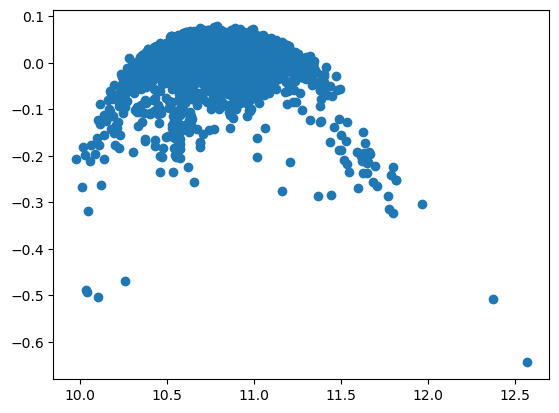

In [44]:
plt.scatter(fitted, residuals)